# Feature Engineering and Hyperparameter Tuning

## Overview

Day 4 focuses on two main tasks: creating useful features and tuning a model with `GridSearchCV`.

I start with the COVID-19 classification dataset used in the earlier work so I can keep the same prediction problem and measure the effect of changing the features and model settings.

I then use the Credit Card Default dataset as a second experiment. The COVID-19 predictors are mostly binary symptom indicators, so the amount of meaningful feature engineering is limited. The credit dataset contains six months of repayment, bill, and payment history, which gives more room to create features that summarize customer behavior.

For both experiments I follow the same process:

**baseline → feature engineering → GridSearchCV → comparison**

## Day 4 Objectives

By the end of this notebook, I will:

1. Keep a held-out test set outside feature selection and tuning.
2. Create and explain useful engineered features.
3. Compare feature sets using the same 5-fold stratified cross-validation.
4. Tune Random Forest hyperparameters with `GridSearchCV`.
5. Compare the baseline, engineered, and tuned models.
6. Identify the engineered feature and hyperparameter that had the largest observed effect.

# Part A — COVID-19 Experiment

I start with the same COVID-19 classification problem used earlier so I can see what changes when I modify the features and Random Forest settings.

## 1. Import the Required Libraries

Pandas and NumPy are used for data preparation, Matplotlib for plots, `Path` for the local dataset path, and Scikit-learn for splitting, cross-validation, Random Forest modeling, and grid search.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
)
from sklearn.ensemble import RandomForestClassifier

## 2. Load the COVID-19 Dataset

I use the same dataset from Week 3 so this part can focus on feature engineering and tuning instead of changing the prediction problem.

In [2]:
DATA_PATH = "../../week-3/corona dataset/corona_tested_individuals_ver_006.english.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)

df.head()

,test_date,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,2020-04-30,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,2020-04-30,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,2020-04-30,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


## 3. Focused Dataset Check

The full EDA was already done earlier, so I only check what is needed here: dataset size, target distribution, missing symptom values, and the available date range.

In [3]:
print("Dataset shape:", df.shape)

print("\nTarget counts:")
print(df["corona_result"].value_counts(dropna=False))

print("\nMissing values in symptom columns:")
symptom_columns = [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
]
print(df[symptom_columns].isna().sum())

parsed_dates = pd.to_datetime(df["test_date"])
print("\nDate range:", parsed_dates.min().date(), "to", parsed_dates.max().date())
print("Number of recorded dates:", parsed_dates.nunique())

Dataset shape: (278848, 10)

Target counts:
corona_result
negative    260227
positive     14729
other         3892
Name: count, dtype: int64

Missing values in symptom columns:
cough                  252
fever                  252
sore_throat              1
shortness_of_breath      1
head_ache                1
dtype: int64

Date range: 2020-03-11 to 2020-04-30
Number of recorded dates: 51


## 4. Prepare the Binary Classification Data

The target is restricted to confirmed negative and positive results:

- `negative` → 0
- `positive` → 1

The five symptom columns are kept from the previous work. `test_indication` is converted into two binary indicators for contact with a confirmed case and travel abroad. Rows missing one of the five symptom values are removed, which affects only a small number of observations.

The raw `test_date` is also kept temporarily because one of the engineered features will be derived from it later.

In [4]:
model_df = df[
    df["corona_result"].isin(["negative", "positive"])
].copy()

rows_before = len(model_df)
model_df = model_df.dropna(subset=symptom_columns)

model_df["contact_with_confirmed"] = (
    model_df["test_indication"] == "Contact with confirmed"
).astype(int)

model_df["abroad"] = (
    model_df["test_indication"] == "Abroad"
).astype(int)

model_df["test_date"] = pd.to_datetime(model_df["test_date"])

original_features = symptom_columns + [
    "contact_with_confirmed",
    "abroad",
]

X_raw = model_df[original_features + ["test_date"]].copy()
X_raw[original_features] = X_raw[original_features].astype(int)

y = (
    model_df["corona_result"]
    .map({"negative": 0, "positive": 1})
    .astype(int)
)

print("Rows before removing missing symptom values:", rows_before)
print("Rows available for modeling:", len(model_df))
print("Rows removed:", rows_before - len(model_df))
print("Positive-class rate: {:.2f}%".format(y.mean() * 100))
print("Original model features:", original_features)

Rows before removing missing symptom values: 274956
Rows available for modeling: 274702
Rows removed: 254
Positive-class rate: 5.35%
Original model features: ['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'contact_with_confirmed', 'abroad']


## 5. Separate Development and Held-Out Test Data

The test set is separated before any feature comparison or grid search. I do not use its labels or evaluate a model on it during Day 4.

Grid search fits many Random Forest models, so I use a fixed stratified sample of 40,000 development rows for this experiment. The same working sample is used for every comparison.

In [5]:
X_dev_raw, X_test_raw, y_dev, y_test = train_test_split(
    X_raw,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

X_tune_raw, _, y_tune, _ = train_test_split(
    X_dev_raw,
    y_dev,
    train_size=40000,
    random_state=42,
    stratify=y_dev,
)

split_summary = pd.DataFrame({
    "Split": ["Development", "Held-out test", "Working sample"],
    "Samples": [len(X_dev_raw), len(X_test_raw), len(X_tune_raw)],
    "Use in Day 4": [
        "source for model development",
        "kept aside",
        "feature comparison and GridSearchCV",
    ],
})

print("Development positive rate: {:.2f}%".format(y_dev.mean() * 100))
print("Working-sample positive rate: {:.2f}%".format(y_tune.mean() * 100))

split_summary

Development positive rate: 5.35%
Working-sample positive rate: 5.35%


,Split,Samples,Use in Day 4
0,Development,219761,source for model development
1,Held-out test,54941,kept aside
2,Working sample,40000,feature comparison and GridSearchCV


## 6. Cross-Validation Setup

Every comparison uses the same 5-fold stratified cross-validation setup. This keeps the feature and tuning comparisons fair.

F1-score is used because the positive class is strongly imbalanced.

In [6]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

baseline_model = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
)

## 7. Untuned Random Forest Baseline

Random Forest was one of the classifiers used in the Week 3 classification work, so I keep it as the model for Day 4.

Before changing the features or hyperparameters, I evaluate an untuned Random Forest using the original seven predictors. This gives a baseline under the same sample, folds, and F1 metric used later.

In [7]:
baseline_scores = cross_val_score(
    baseline_model,
    X_tune_raw[original_features],
    y_tune,
    cv=cv,
    scoring="f1",
    n_jobs=1,
)

print("Fold F1-scores:", baseline_scores.round(4))
print("Mean CV F1: {:.4f}".format(baseline_scores.mean()))
print("CV standard deviation: {:.4f}".format(baseline_scores.std()))

Fold F1-scores: [0.6486 0.6232 0.6457 0.662  0.6578]
Mean CV F1: 0.6475
CV standard deviation: 0.0135


## 8. Engineer New Features

Two new features are created from information already available before the test result is known.

### `symptom_count`

This feature counts how many of the five recorded symptoms are present. The original columns show each symptom separately, while the count gives one direct measure of total symptom burden.

### `days_since_start`

The raw date is converted into the number of days from a fixed reference date at the start of the collection period. This tests whether the position in time contains useful signal, since testing conditions and the positive rate changed during the dataset period.

Both transformations are row-level and do not use target values.

In [8]:
REFERENCE_DATE = pd.Timestamp("2020-03-11")


def add_engineered_features(data):
    engineered = data.copy()

    engineered["symptom_count"] = engineered[symptom_columns].sum(axis=1)

    engineered["days_since_start"] = (
        engineered["test_date"] - REFERENCE_DATE
    ).dt.days.astype(int)

    return engineered


X_tune = add_engineered_features(X_tune_raw)

engineered_features = ["symptom_count", "days_since_start"]
all_features = original_features + engineered_features

X_tune[original_features + engineered_features].head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,contact_with_confirmed,abroad,symptom_count,days_since_start
224036,0,0,0,0,0,0,0,0,19
102196,0,0,0,0,0,0,0,0,37
141984,0,1,0,0,0,0,0,1,32
26321,0,0,0,0,0,0,0,0,46
154429,0,1,0,0,0,0,0,1,29


## 9. Measure the Effect of the Engineered Features

To see what each new feature actually changes, I keep the model and folds fixed and compare four feature sets:

1. Original features only.
2. Original features + `symptom_count`.
3. Original features + `days_since_start`.
4. Original features + both engineered features.

In [9]:
feature_sets = {
    "Original features": original_features,
    "Original + symptom_count": original_features + ["symptom_count"],
    "Original + days_since_start": original_features + ["days_since_start"],
    "Original + both engineered features": all_features,
}

feature_results = []

for name, columns in feature_sets.items():
    scores = cross_val_score(
        RandomForestClassifier(random_state=42, n_jobs=1),
        X_tune[columns],
        y_tune,
        cv=cv,
        scoring="f1",
        n_jobs=1,
    )

    feature_results.append({
        "Feature Set": name,
        "Mean CV F1": scores.mean(),
        "CV Std": scores.std(),
    })

feature_results_df = pd.DataFrame(feature_results)
feature_results_df.round(4)

,Feature Set,Mean CV F1,CV Std
0,Original features,0.6475,0.0135
1,Original + symptom_count,0.6475,0.0135
2,Original + days_since_start,0.6684,0.0076
3,Original + both engineered features,0.6695,0.0078


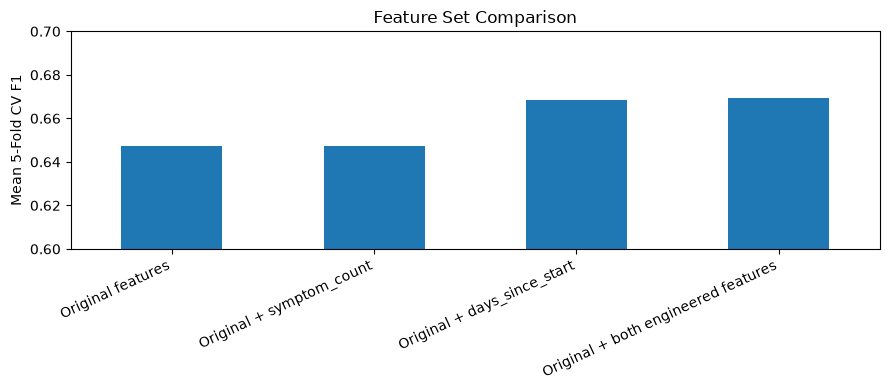

In [10]:
plot_data = feature_results_df.set_index("Feature Set")["Mean CV F1"]

ax = plot_data.plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Mean 5-Fold CV F1")
ax.set_xlabel("")
ax.set_title("Feature Set Comparison")
ax.set_ylim(0.60, 0.70)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

### Feature Engineering Result

`days_since_start` gives the clear improvement in this experiment. `symptom_count` does not improve F1 by itself, while using both engineered features gives a small additional gain over the date feature alone.

The date feature should still be treated carefully. Its improvement may reflect changes in testing conditions during this specific collection period, so I would not assume that the same effect will generalize to a different time period.

## 10. Parameters vs. Hyperparameters

A **parameter** is learned during model fitting. In a Random Forest, the split rules inside the individual trees are examples of learned parameters.

A **hyperparameter** is chosen before training and controls how the model is built. For this experiment, the grid search changes:

- `n_estimators`: number of trees in the forest.
- `max_depth`: maximum depth allowed for each tree.
- `min_samples_leaf`: minimum number of samples required in a leaf node.

These settings affect model capacity, stability, and computation time.

## 11. Define the Hyperparameter Grid

I use a small grid so every combination can be tested with 5-fold cross-validation without making the notebook unnecessarily slow.

There are eight parameter combinations, which means 40 model fits across the five folds.

For a much larger search space, `RandomizedSearchCV` would be a more practical option. Here the grid is small enough to test every combination.

In [11]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_leaf": [3, 5],
}

number_of_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_leaf"])
)

print("Grid combinations:", number_of_combinations)
print("Total CV fits:", number_of_combinations * cv.get_n_splits())
print(param_grid)

Grid combinations: 8
Total CV fits: 40
{'n_estimators': [100, 200], 'max_depth': [10, None], 'min_samples_leaf': [3, 5]}


## 12. Tune the Random Forest with GridSearchCV

`GridSearchCV` evaluates every parameter combination using the same 5-fold stratified setup. The best model is selected using mean F1 across the validation folds.

In [12]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=1,
    ),
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=1,
    return_train_score=True,
)

grid_search.fit(
    X_tune[all_features],
    y_tune,
)

best_cv_std = grid_search.cv_results_["std_test_score"][grid_search.best_index_]

print("Best parameters:", grid_search.best_params_)
print(
    "Best mean CV F1: {:.4f} ± {:.4f}".format(
        grid_search.best_score_,
        best_cv_std,
    )
)

Best parameters: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Best mean CV F1: 0.6888 ± 0.0098


## 13. Inspect the Grid Search Results

I keep the full results table instead of showing only the best row. This makes it easier to see how close the different parameter combinations are.

In [13]:
grid_results = pd.DataFrame(grid_search.cv_results_)

result_columns = [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score",
]

ranked_grid_results = (
    grid_results[result_columns]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)

ranked_grid_results.round(4)

,param_n_estimators,param_max_depth,param_min_samples_leaf,mean_test_score,std_test_score,mean_train_score,rank_test_score
0,200,None,5,0.6888,0.0098,0.7067,1
1,100,None,5,0.6882,0.0094,0.7063,2
2,100,10,5,0.6864,0.0100,0.6990,3
3,200,10,5,0.6862,0.0132,0.6981,4
4,200,10,3,0.6837,0.0123,0.7030,5
5,100,10,3,0.6823,0.0099,0.7026,6
6,100,None,3,0.6813,0.0076,0.7137,7
7,200,None,3,0.6810,0.0073,0.7139,8


## 14. Compare Baseline, Feature Engineering, and Tuning

The comparison separates the effect of feature engineering from the effect of hyperparameter tuning.

- The first row is the untuned Random Forest using the original Week 3-style feature set.
- The second row keeps the model untuned but adds the two engineered features.
- The third row uses the same engineered features with the best grid-search configuration.

In [14]:
original_mean = feature_results_df.loc[
    feature_results_df["Feature Set"] == "Original features",
    "Mean CV F1",
].iloc[0]

original_std = feature_results_df.loc[
    feature_results_df["Feature Set"] == "Original features",
    "CV Std",
].iloc[0]

engineered_mean = feature_results_df.loc[
    feature_results_df["Feature Set"] == "Original + both engineered features",
    "Mean CV F1",
].iloc[0]

engineered_std = feature_results_df.loc[
    feature_results_df["Feature Set"] == "Original + both engineered features",
    "CV Std",
].iloc[0]

comparison_df = pd.DataFrame({
    "Model": [
        "Untuned Random Forest - original features",
        "Untuned Random Forest - engineered features",
        "Tuned Random Forest - engineered features",
    ],
    "Mean CV F1": [
        original_mean,
        engineered_mean,
        grid_search.best_score_,
    ],
    "CV Std": [
        original_std,
        engineered_std,
        grid_search.cv_results_["std_test_score"][grid_search.best_index_],
    ],
})

comparison_df["Improvement vs. Original"] = (
    comparison_df["Mean CV F1"] - original_mean
)

comparison_df.round(4)

,Model,Mean CV F1,CV Std,Improvement vs. Original
0,Untuned Random Forest - original features,0.6475,0.0135,0.0000
1,Untuned Random Forest - engineered features,0.6695,0.0078,0.0220
2,Tuned Random Forest - engineered features,0.6888,0.0098,0.0413


### Model Comparison Result

The three stages are:

- baseline Random Forest: **0.6475 ± 0.0135** mean CV F1,
- engineered features: **0.6695 ± 0.0078**,
- tuned model: **0.6888 ± 0.0098**.

Feature engineering adds about **0.0220 F1** over the baseline. Tuning adds about **0.0193** more. Overall, the tuned model gains about **0.0413 F1**, which is roughly a **6.38% relative improvement** over the original baseline.

## 15. Which Engineered Feature Mattered Most?

Each engineered feature is added separately to the original feature set and evaluated with the same folds. This gives a direct comparison of their individual effects.

In [15]:
feature_score_lookup = feature_results_df.set_index("Feature Set")["Mean CV F1"]

feature_effects = pd.DataFrame({
    "Engineered Feature": ["symptom_count", "days_since_start"],
    "Mean CV F1 When Added Alone": [
        feature_score_lookup["Original + symptom_count"],
        feature_score_lookup["Original + days_since_start"],
    ],
})

feature_effects["Change vs. Original"] = (
    feature_effects["Mean CV F1 When Added Alone"] - original_mean
)

feature_effects.sort_values(
    "Change vs. Original",
    ascending=False,
).round(4)

,Engineered Feature,Mean CV F1 When Added Alone,Change vs. Original
1,days_since_start,0.6684,0.021
0,symptom_count,0.6475,0.000


### Feature Impact

`days_since_start` is the feature with the largest observed effect. It improves mean CV F1 by about **0.0210** when added to the original feature set.

`symptom_count` does not provide a measurable improvement on its own in this Random Forest setup. This is reasonable because a Random Forest can already combine the individual symptom indicators through its tree splits. The date-derived feature adds information that was not present in the original seven predictors.

## 16. Which Hyperparameter Mattered Most?

To get a simple view of parameter impact, I group the grid-search scores by each tested value and compare the range of the grouped mean F1-scores.

In [16]:
parameter_effect_rows = []

for parameter in [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_leaf",
]:
    grouped = (
        grid_results
        .assign(**{parameter: grid_results[parameter].astype(str)})
        .groupby(parameter)["mean_test_score"]
        .mean()
    )

    parameter_effect_rows.append({
        "Hyperparameter": parameter.replace("param_", ""),
        "Lowest Group Mean F1": grouped.min(),
        "Highest Group Mean F1": grouped.max(),
        "Observed Range": grouped.max() - grouped.min(),
    })

parameter_effects_df = pd.DataFrame(parameter_effect_rows)
parameter_effects_df.sort_values(
    "Observed Range",
    ascending=False,
).round(4)

,Hyperparameter,Lowest Group Mean F1,Highest Group Mean F1,Observed Range
2,min_samples_leaf,0.6821,0.6874,0.0053
0,n_estimators,0.6845,0.6849,0.0004
1,max_depth,0.6846,0.6846,0.0000


### Hyperparameter Impact

Among the values tested, `min_samples_leaf` has the largest effect on mean cross-validated F1. The configurations using `min_samples_leaf=5` are consistently stronger than those using `3` in this grid.

Changing `n_estimators` from 100 to 200 has only a small average effect, while the tested `max_depth` values are also close on average. This means the leaf-size setting mattered more than simply increasing the number of trees in this experiment.

## 17. Selected Configuration

The best parameter combination found by `GridSearchCV` is kept as the selected configuration for this experiment.

In [17]:
best_model = grid_search.best_estimator_

print(best_model)

RandomForestClassifier(min_samples_leaf=5, n_estimators=200, n_jobs=1,
                       random_state=42)


## 18. Part A Summary

The COVID-19 experiment shows three main things:

- `days_since_start` was more useful than `symptom_count`.
- Feature engineering improved the untuned Random Forest.
- Grid search improved the model again, with `min_samples_leaf` showing the largest effect inside the tested grid.

The held-out test set was not used during feature selection or tuning.

# Part B — Credit Card Default Experiment

## 19. Why Use a Second Dataset?

The COVID-19 experiment covers the Day 4 workflow, but most of its predictors are yes/no symptom indicators. That limits the kinds of new features I can create.

The Credit Card Default dataset has six months of repayment status, bill amounts, and payment amounts. That gives me more useful raw information for feature engineering, especially features that summarize repeated financial behavior over time.

I use the same Day 4 process again: build a baseline, test engineered features, tune the model with 5-fold cross-validation, and compare the results.

## 20. Load the Credit Card Default Dataset

The dataset is stored as a CSV inside the `data` folder so it can be loaded directly with Pandas.

The target column is `default payment next month`:

- `0` → no default next month
- `1` → default next month

In [18]:
credit_data_path = Path("data/default_credit_card_clients.csv")

credit_df = pd.read_csv(credit_data_path)

print("Loaded:", credit_data_path)
print("Dataset shape:", credit_df.shape)

credit_df.head()

Loaded: data\default_credit_card_clients.csv
Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## 21. Focused Dataset Check

I only check the values needed before modeling:

- number of rows and columns,
- missing values,
- duplicate rows,
- whether `ID` is unique,
- target counts and percentages.

The target is imbalanced, so F1-score for class `1` is more informative here than accuracy alone.

In [19]:

credit_target = "default payment next month"

target_counts = credit_df[credit_target].value_counts().sort_index()
target_percentages = (target_counts / len(credit_df) * 100).round(2)

print("Rows:", len(credit_df))
print("Columns:", credit_df.shape[1])
print("Total missing values:", int(credit_df.isna().sum().sum()))
print("Duplicate rows:", int(credit_df.duplicated().sum()))
print("ID is unique:", bool(credit_df["ID"].is_unique))

target_summary = pd.DataFrame({
    "Class": ["No default (0)", "Default (1)"],
    "Count": [target_counts.loc[0], target_counts.loc[1]],
    "Percentage (%)": [target_percentages.loc[0], target_percentages.loc[1]],
})
target_summary


Rows: 30000
Columns: 25
Total missing values: 0
Duplicate rows: 0
ID is unique: True


,Class,Count,Percentage (%)
0,No default (0),23364,77.88
1,Default (1),6636,22.12


### Target Distribution

The default class is **22.12%** of the dataset, so the classes are imbalanced.

A classifier that predicts "no default" for every record would already get **77.88% accuracy**, even though it would detect none of the default cases. For that reason, I use F1-score for class `1` as the main model-selection metric and keep the folds stratified.

This also means that an F1 value such as `0.53` is **not** the same thing as 53% accuracy.

## 22. Prepare Development and Test Data

`ID` is removed because it is only an identifier.

I keep 20% of the data as a held-out test set and use the remaining 80% as development data. Since the feature comparisons and grid search fit many Random Forest models, I take a fixed stratified sample of 12,000 development rows for the Day 4 work.

The same working sample and the same folds are used in all Part B comparisons. The held-out test set is kept aside and is not evaluated during tuning.

In [20]:
X_credit = credit_df.drop(columns=["ID", credit_target])
y_credit = credit_df[credit_target].astype(int)

X_credit_dev, X_credit_test, y_credit_dev, y_credit_test = train_test_split(
    X_credit,
    y_credit,
    test_size=0.20,
    random_state=42,
    stratify=y_credit,
)

X_credit_tune, _, y_credit_tune, _ = train_test_split(
    X_credit_dev,
    y_credit_dev,
    train_size=12_000,
    random_state=42,
    stratify=y_credit_dev,
)

credit_split_summary = pd.DataFrame({
    "Split": ["Full dataset", "Development", "Held-out test", "Working sample"],
    "Samples": [
        len(X_credit),
        len(X_credit_dev),
        len(X_credit_test),
        len(X_credit_tune),
    ],
    "Use in Day 4": [
        "source data",
        "source for model development",
        "kept aside",
        "feature comparison and GridSearchCV",
    ],
})

print("Development default rate: {:.2f}%".format(y_credit_dev.mean() * 100))
print("Working-sample default rate: {:.2f}%".format(y_credit_tune.mean() * 100))

credit_split_summary

Development default rate: 22.12%
Working-sample default rate: 22.12%


,Split,Samples,Use in Day 4
0,Full dataset,30000,source data
1,Development,24000,source for model development
2,Held-out test,6000,kept aside
3,Working sample,12000,feature comparison and GridSearchCV


## 23. Credit Default Baseline

The baseline uses the original predictors, with `ID` removed.

It is evaluated using:

- 5-fold `StratifiedKFold`
- `random_state=42`
- F1-score for the default class
- no test-set feedback

In [21]:

credit_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

credit_baseline_model = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
)

credit_baseline_scores = cross_val_score(
    credit_baseline_model,
    X_credit_tune,
    y_credit_tune,
    cv=credit_cv,
    scoring="f1",
    n_jobs=1,
)

credit_baseline_mean = credit_baseline_scores.mean()
credit_baseline_std = credit_baseline_scores.std()

print("Fold F1-scores:", credit_baseline_scores.round(4))
print(f"Mean CV F1: {credit_baseline_mean:.4f}")
print(f"CV standard deviation: {credit_baseline_std:.4f}")
print(f"Mean CV F1 as percentage: {credit_baseline_mean * 100:.2f}%")


Fold F1-scores: [0.47   0.4561 0.4409 0.4685 0.4843]
Mean CV F1: 0.4640
CV standard deviation: 0.0146
Mean CV F1 as percentage: 46.40%


### Baseline Result

The baseline score printed above is the reference point for Part B. All feature-engineering and tuning results are compared against it using the same five folds.

## 24. Engineer New Credit Features

The dataset contains six months of repayment, bill, and payment history. I use those repeated columns to create summary features without using the target.

### Repayment behavior

- **`months_with_delay`**: number of months with a positive delay status.
- **`max_delay`**: worst delay status across the six months.
- **`avg_delay`**: average delay after treating early/on-time negative codes as zero.

### Balance and utilization

- **`avg_bill_amount`**: average billed amount across six months.
- **`avg_credit_utilization`**: average bill amount divided by the credit limit.

### Payment coverage and trends

- **`payment_to_bill_ratio`**: total payments divided by total non-negative billed amounts.
- **`bill_change_ratio`**: change from the oldest bill to the most recent bill, scaled by credit limit.
- **`payment_change_ratio`**: change from the oldest payment to the most recent payment, scaled by credit limit.

These features summarize repeated monthly columns into values that may be easier for the model to use.

In [22]:

credit_pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
credit_bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
credit_payment_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

def add_credit_engineered_features(data):
    engineered = data.copy()

    delay_values = engineered[credit_pay_status_cols]

    engineered["months_with_delay"] = (delay_values > 0).sum(axis=1)
    engineered["max_delay"] = delay_values.max(axis=1)
    engineered["avg_delay"] = delay_values.clip(lower=0).mean(axis=1)

    engineered["avg_bill_amount"] = engineered[credit_bill_cols].mean(axis=1)
    engineered["avg_credit_utilization"] = (
        engineered["avg_bill_amount"]
        / engineered["LIMIT_BAL"].replace(0, np.nan)
    )

    positive_bills = engineered[credit_bill_cols].clip(lower=0)
    engineered["payment_to_bill_ratio"] = (
        engineered[credit_payment_cols].sum(axis=1)
        / (positive_bills.sum(axis=1) + 1.0)
    )

    engineered["bill_change_ratio"] = (
        engineered["BILL_AMT1"] - engineered["BILL_AMT6"]
    ) / engineered["LIMIT_BAL"].replace(0, np.nan)

    engineered["payment_change_ratio"] = (
        engineered["PAY_AMT1"] - engineered["PAY_AMT6"]
    ) / engineered["LIMIT_BAL"].replace(0, np.nan)

    return (
        engineered
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

X_credit_tune_engineered = add_credit_engineered_features(X_credit_tune)

credit_engineered_features = [
    "months_with_delay",
    "max_delay",
    "avg_delay",
    "avg_bill_amount",
    "avg_credit_utilization",
    "payment_to_bill_ratio",
    "bill_change_ratio",
    "payment_change_ratio",
]

print("Original feature count:", X_credit_tune.shape[1])
print("Engineered feature count:", len(credit_engineered_features))
print("Final feature count:", X_credit_tune_engineered.shape[1])

X_credit_tune_engineered[credit_engineered_features].head()


Original feature count: 23
Engineered feature count: 8
Final feature count: 31


,months_with_delay,max_delay,avg_delay,avg_bill_amount,avg_credit_utilization,payment_to_bill_ratio,bill_change_ratio,payment_change_ratio
6775,0,0,0.000000,21274.000000,0.163646,0.102519,-0.026838,0.015385
15883,1,2,0.333333,10582.166667,0.117580,0.109333,0.015700,-0.005556
11575,0,0,0.000000,15489.500000,0.067346,0.426446,0.049417,0.017887
28882,0,0,0.000000,47865.000000,0.957300,0.062676,-0.069480,0.040000
10459,6,2,2.000000,46285.333333,0.925707,0.034568,-0.060440,0.004000


## 25. Test the Engineered Features

I add each engineered feature one at a time to the original predictors and evaluate it with the same Random Forest and the same five folds. After that, I test all engineered features together.

This lets me see which individual feature helps most and whether the full engineered set improves the baseline.

In [23]:

credit_original_features = list(X_credit_tune.columns)

credit_feature_sets = {
    "Original features": credit_original_features,
}

for feature in credit_engineered_features:
    credit_feature_sets[f"Original + {feature}"] = (
        credit_original_features + [feature]
    )

credit_feature_sets["Original + all engineered features"] = list(
    X_credit_tune_engineered.columns
)

credit_feature_results = []

for name, columns in credit_feature_sets.items():
    scores = cross_val_score(
        credit_baseline_model,
        X_credit_tune_engineered[columns],
        y_credit_tune,
        cv=credit_cv,
        scoring="f1",
        n_jobs=1,
    )

    credit_feature_results.append({
        "Feature Set": name,
        "Mean CV F1": scores.mean(),
        "CV Std": scores.std(),
    })

credit_feature_results_df = pd.DataFrame(credit_feature_results)

credit_feature_results_df["Absolute Change"] = (
    credit_feature_results_df["Mean CV F1"] - credit_baseline_mean
)

credit_feature_results_df["Relative Change (%)"] = (
    credit_feature_results_df["Absolute Change"]
    / credit_baseline_mean
    * 100
)

credit_feature_results_df.sort_values(
    "Mean CV F1",
    ascending=False,
).round(4)


,Feature Set,Mean CV F1,CV Std,Absolute Change,Relative Change (%)
9,Original + all engineered features,0.4734,0.0192,0.0094,2.0325
2,Original + max_delay,0.4730,0.0148,0.0090,1.9425
4,Original + avg_bill_amount,0.4693,0.0122,0.0054,1.1561
1,Original + months_with_delay,0.4693,0.0148,0.0053,1.1380
7,Original + bill_change_ratio,0.4668,0.0100,0.0028,0.5999
3,Original + avg_delay,0.4651,0.0139,0.0011,0.2335
5,Original + avg_credit_utilization,0.4647,0.0181,0.0007,0.1456
8,Original + payment_change_ratio,0.4644,0.0195,0.0004,0.0860
0,Original features,0.4640,0.0146,0.0000,0.0000
6,Original + payment_to_bill_ratio,0.4609,0.0152,-0.0031,-0.6623


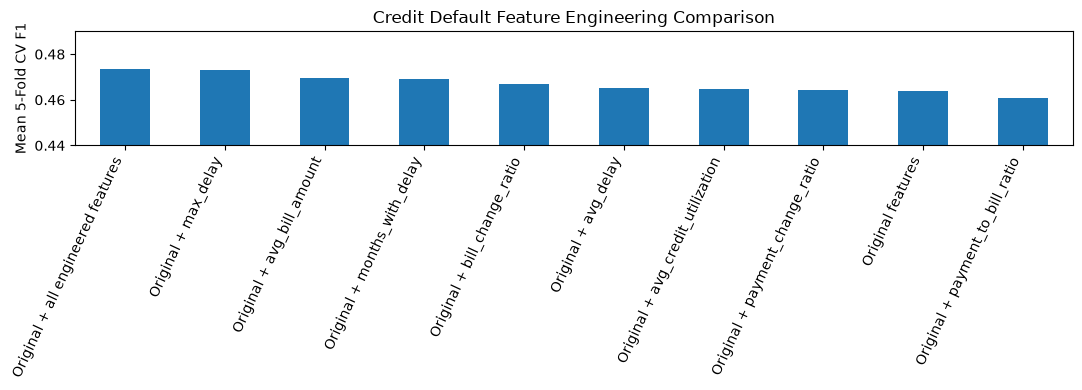

In [24]:

credit_feature_plot = (
    credit_feature_results_df
    .set_index("Feature Set")["Mean CV F1"]
    .sort_values(ascending=False)
)

ax = credit_feature_plot.plot(
    kind="bar",
    figsize=(11, 4),
)

ax.set_ylabel("Mean 5-Fold CV F1")
ax.set_xlabel("")
ax.set_title("Credit Default Feature Engineering Comparison")
ax.set_ylim(0.44, 0.49)

plt.xticks(rotation=65, ha="right")
plt.tight_layout()
plt.show()


### Feature Engineering Result

`max_delay` is the strongest individual engineered feature in this run. The full engineered feature set performs slightly better than the original predictors.

`payment_to_bill_ratio` is a useful example of why features still need to be tested: it makes sense financially, but by itself it slightly lowers the F1-score for this Random Forest.

## 26. Parameters vs. Hyperparameters

A model **parameter** is learned during `.fit()`. For a Random Forest, the split rules inside the trees are learned from the training data.

A **hyperparameter** is chosen before training and changes how the model is built.

For Part B, I tune:

- `max_depth` — controls tree depth,
- `min_samples_leaf` — controls the minimum number of samples in a leaf,
- `class_weight` — changes how much weight the minority default class receives.

`n_estimators` stays fixed at 100 so the grid remains small enough to inspect easily.

I do not standardize the numeric features here because Random Forest is a tree-based model and does not require features to be on the same scale.

## 27. Tune the Engineered Model with GridSearchCV

The grid tests two values for each of three hyperparameters, so there are eight combinations. With five folds, that gives 40 validation fits.

I include `class_weight="balanced"` because the default class is the minority class and F1 depends on both precision and recall.

The grid is small enough for `GridSearchCV`; for a much larger set of combinations, `RandomizedSearchCV` would reduce the number of fits.

In [25]:

credit_param_grid = {
    "max_depth": [8, None],
    "min_samples_leaf": [1, 5],
    "class_weight": [None, "balanced"],
}

credit_grid_combinations = (
    len(credit_param_grid["max_depth"])
    * len(credit_param_grid["min_samples_leaf"])
    * len(credit_param_grid["class_weight"])
)

print("Grid combinations:", credit_grid_combinations)
print("Total CV fits:", credit_grid_combinations * credit_cv.get_n_splits())
print(credit_param_grid)


Grid combinations: 8
Total CV fits: 40
{'max_depth': [8, None], 'min_samples_leaf': [1, 5], 'class_weight': [None, 'balanced']}


In [26]:
credit_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid=credit_param_grid,
    cv=credit_cv,
    scoring="f1",
    n_jobs=1,
    return_train_score=True,
)

credit_grid_search.fit(
    X_credit_tune_engineered,
    y_credit_tune,
)

credit_tuned_mean = credit_grid_search.best_score_
credit_tuned_std = credit_grid_search.cv_results_[
    "std_test_score"
][credit_grid_search.best_index_]

print("Best parameters:", credit_grid_search.best_params_)
print(f"Best mean CV F1: {credit_tuned_mean:.4f} ± {credit_tuned_std:.4f}")
print(f"Best mean CV F1 as percentage: {credit_tuned_mean * 100:.2f}%")

Best parameters: {'class_weight': 'balanced', 'max_depth': 8, 'min_samples_leaf': 1}
Best mean CV F1: 0.5393 ± 0.0094
Best mean CV F1 as percentage: 53.93%


### GridSearchCV Result

The best configuration uses:

- `class_weight="balanced"`
- `max_depth=8`
- `min_samples_leaf=1`

Its mean 5-fold CV F1 is **0.5393 ± 0.0094**.

The `53.93%` value shown above is the F1-score written as a percentage. It should not be interpreted as model accuracy.

## 28. Inspect the Full Grid Search

The full grid table is shown so I can compare the winning configuration with the other tested settings.

`mean_train_score` is included as a diagnostic for overfitting. Model selection still uses `mean_test_score`, which is the cross-validated validation score.

In [27]:

credit_grid_results = pd.DataFrame(
    credit_grid_search.cv_results_
).sort_values("rank_test_score")

credit_grid_columns = [
    "param_max_depth",
    "param_min_samples_leaf",
    "param_class_weight",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "rank_test_score",
]

credit_grid_results[
    credit_grid_columns
].round(4)


,param_max_depth,param_min_samples_leaf,param_class_weight,mean_test_score,std_test_score,mean_train_score,rank_test_score
4,8,1,balanced,0.5393,0.0094,0.6263,1
7,None,5,balanced,0.5385,0.0048,0.8357,2
5,8,5,balanced,0.5377,0.0127,0.6123,3
6,None,1,balanced,0.5286,0.0098,0.9941,4
3,None,5,NaN,0.4774,0.0103,0.6777,5
2,None,1,NaN,0.4734,0.0192,0.9993,6
0,8,1,NaN,0.4729,0.0137,0.5717,7
1,8,5,NaN,0.4714,0.0138,0.5512,8


Some unrestricted-tree settings have a much higher training F1 than validation F1, which is a sign of overfitting.

The grid also shows that balanced class weighting changes the result noticeably. This connects the Day 4 tuning step back to the bias-variance ideas from Day 3.

## 29. Compare the Improvement

I compare three stages using the same cross-validation setup:

1. untuned Random Forest with the original features,
2. untuned Random Forest with all engineered features,
3. tuned Random Forest with all engineered features.

The code reports both the absolute F1 change and the relative percentage improvement.

In [28]:
credit_engineered_row = credit_feature_results_df.loc[
    credit_feature_results_df["Feature Set"]
    == "Original + all engineered features"
].iloc[0]

credit_engineered_mean = credit_engineered_row["Mean CV F1"]
credit_engineered_std = credit_engineered_row["CV Std"]

credit_stage_summary = pd.DataFrame({
    "Stage": [
        "Baseline: original features",
        "Untuned: all engineered features",
        "Tuned: engineered features",
    ],
    "Mean CV F1": [
        credit_baseline_mean,
        credit_engineered_mean,
        credit_tuned_mean,
    ],
    "CV Std": [
        credit_baseline_std,
        credit_engineered_std,
        credit_tuned_std,
    ],
})

credit_stage_summary["F1 (%)"] = (
    credit_stage_summary["Mean CV F1"] * 100
)

credit_stage_summary["Absolute Gain vs Baseline"] = (
    credit_stage_summary["Mean CV F1"] - credit_baseline_mean
)

credit_stage_summary["Relative Improvement vs Baseline (%)"] = (
    credit_stage_summary["Absolute Gain vs Baseline"]
    / credit_baseline_mean
    * 100
)

credit_stage_summary.round(4)

,Stage,Mean CV F1,CV Std,F1 (%),Absolute Gain vs Baseline,Relative Improvement vs Baseline (%)
0,Baseline: original features,0.4640,0.0146,46.3983,0.0000,0.0000
1,Untuned: all engineered features,0.4734,0.0192,47.3414,0.0094,2.0325
2,Tuned: engineered features,0.5393,0.0094,53.9314,0.0753,16.2357


In [29]:

credit_feature_relative_gain = (
    (credit_engineered_mean / credit_baseline_mean) - 1
) * 100

credit_tuning_relative_gain = (
    (credit_tuned_mean / credit_engineered_mean) - 1
) * 100

credit_total_relative_gain = (
    (credit_tuned_mean / credit_baseline_mean) - 1
) * 100

print(
    f"Feature engineering gain: "
    f"{credit_engineered_mean - credit_baseline_mean:.4f} F1 "
    f"({credit_feature_relative_gain:.2f}% relative)"
)

print(
    f"Tuning gain after feature engineering: "
    f"{credit_tuned_mean - credit_engineered_mean:.4f} F1 "
    f"({credit_tuning_relative_gain:.2f}% relative)"
)

print(
    f"Total baseline-to-tuned gain: "
    f"{credit_tuned_mean - credit_baseline_mean:.4f} F1 "
    f"({credit_total_relative_gain:.2f}% relative)"
)


Feature engineering gain: 0.0094 F1 (2.03% relative)
Tuning gain after feature engineering: 0.0659 F1 (13.92% relative)
Total baseline-to-tuned gain: 0.0753 F1 (16.24% relative)


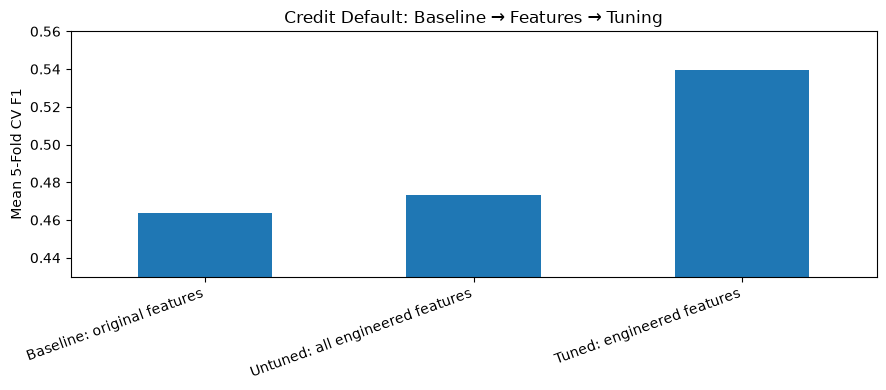

In [30]:

ax = (
    credit_stage_summary
    .set_index("Stage")["Mean CV F1"]
    .plot(kind="bar", figsize=(9, 4))
)

ax.set_ylabel("Mean 5-Fold CV F1")
ax.set_xlabel("")
ax.set_title("Credit Default: Baseline → Features → Tuning")
ax.set_ylim(0.43, 0.56)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Improvement Result

Feature engineering gives a small positive improvement, and the larger gain comes from hyperparameter tuning.

The final change from the original baseline to the tuned model is about **+0.0753 F1**. Relative to the baseline F1, that is about **16.24% improvement**.

These are two different ways to describe the same change:

- **absolute gain**: `tuned F1 - baseline F1`
- **relative improvement**: `absolute gain / baseline F1 × 100`

## 30. Which Engineered Feature Mattered Most?

In [31]:

credit_individual_feature_effects = (
    credit_feature_results_df[
        credit_feature_results_df["Feature Set"].str.startswith("Original + ")
        & (
            credit_feature_results_df["Feature Set"]
            != "Original + all engineered features"
        )
    ]
    .copy()
)

credit_individual_feature_effects["Engineered Feature"] = (
    credit_individual_feature_effects["Feature Set"]
    .str.replace("Original + ", "", regex=False)
)

credit_individual_feature_effects = (
    credit_individual_feature_effects[
        [
            "Engineered Feature",
            "Mean CV F1",
            "Absolute Change",
            "Relative Change (%)",
        ]
    ]
    .sort_values("Mean CV F1", ascending=False)
)

credit_individual_feature_effects.round(4)


,Engineered Feature,Mean CV F1,Absolute Change,Relative Change (%)
2,max_delay,0.4730,0.0090,1.9425
4,avg_bill_amount,0.4693,0.0054,1.1561
1,months_with_delay,0.4693,0.0053,1.1380
7,bill_change_ratio,0.4668,0.0028,0.5999
3,avg_delay,0.4651,0.0011,0.2335
5,avg_credit_utilization,0.4647,0.0007,0.1456
8,payment_change_ratio,0.4644,0.0004,0.0860
6,payment_to_bill_ratio,0.4609,-0.0031,-0.6623


`max_delay` has the largest individual effect in the feature comparison. It summarizes the worst repayment problem seen across the six monthly status columns.

The full engineered set performs a little better than `max_delay` alone, so the other summary features still add some useful information together.

## 31. Which Hyperparameter Mattered Most?

In [32]:
credit_parameter_effect_rows = []

for parameter in [
    "param_max_depth",
    "param_min_samples_leaf",
    "param_class_weight",
]:
    grouped_scores = (
        credit_grid_results
        .groupby(parameter, dropna=False)["mean_test_score"]
        .mean()
    )

    credit_parameter_effect_rows.append({
        "Hyperparameter": parameter.replace("param_", ""),
        "Best Grouped Mean F1": grouped_scores.max(),
        "Worst Grouped Mean F1": grouped_scores.min(),
        "Observed Range": grouped_scores.max() - grouped_scores.min(),
    })

credit_parameter_effects = (
    pd.DataFrame(credit_parameter_effect_rows)
    .sort_values("Observed Range", ascending=False)
)

credit_parameter_effects.round(4)

,Hyperparameter,Best Grouped Mean F1,Worst Grouped Mean F1,Observed Range
2,class_weight,0.5360,0.4738,0.0623
1,min_samples_leaf,0.5062,0.5036,0.0027
0,max_depth,0.5053,0.5045,0.0008


`class_weight` has the largest observed effect across the tested grid.

That makes sense for this dataset because the default class is the minority class. Giving it more weight changes the precision-recall trade-off and has a much larger effect on F1 than the other tested settings.

## 32. Summary of Both Experiments

The two datasets have different class distributions and different prediction difficulty, so I do not judge them by asking which one has the larger raw F1-score.

The useful comparison is the process inside each experiment: start from its own baseline, test the engineered features, tune the model, and measure how much the score improves.

In [33]:
cross_dataset_summary = pd.DataFrame({
    "Study": [
        "COVID-19",
        "Credit Card Default",
    ],
    "Baseline CV F1": [
        original_mean,
        credit_baseline_mean,
    ],
    "Engineered CV F1": [
        engineered_mean,
        credit_engineered_mean,
    ],
    "Tuned CV F1": [
        grid_search.best_score_,
        credit_tuned_mean,
    ],
})

cross_dataset_summary["Absolute Baseline-to-Tuned Gain"] = (
    cross_dataset_summary["Tuned CV F1"]
    - cross_dataset_summary["Baseline CV F1"]
)

cross_dataset_summary["Relative Baseline-to-Tuned Gain (%)"] = (
    cross_dataset_summary["Absolute Baseline-to-Tuned Gain"]
    / cross_dataset_summary["Baseline CV F1"]
    * 100
)

cross_dataset_summary.round(4)

,Study,Baseline CV F1,Engineered CV F1,Tuned CV F1,Absolute Baseline-to-Tuned Gain,Relative Baseline-to-Tuned Gain (%)
0,COVID-19,0.6475,0.6695,0.6888,0.0413,6.3783
1,Credit Card Default,0.4640,0.4734,0.5393,0.0753,16.2357


## 33. Conclusion

The COVID-19 experiment keeps Day 4 connected to the earlier classification work. `days_since_start` was the useful engineered feature there, and tuning improved the Random Forest again after feature engineering.

I added the Credit Card Default dataset because its repeated monthly financial variables allow more meaningful feature construction than the mostly binary COVID-19 predictors. In this experiment, `max_delay` was the strongest individual engineered feature, while `class_weight` had the largest effect among the tested hyperparameters.

Both experiments use 5-fold stratified cross-validation for development, and the held-out test sets remain outside feature selection and hyperparameter tuning.